# Element Visualization

This notebook visualizes the optimized diffractive element profiles from the N-element sweep study. It loads results from the sweep, extracts the binary (binarized) element transmission profiles, and plots them as physical structures to show what the designed cascade elements look like in real space.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from src.util import gaussian_energy_spectrum, spherize_1d_array 
from src.simparams import SimParams
from src.inversedesign_utils import zp_init

In [14]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

## Load sweep results

Load the optimized element density profiles (`opt_rhos`) and simulation parameters from the N-element sweep. The profiles are stored as half-elements due to radial symmetry and are mirrored here to recover the full profile.

In [4]:
path = repo_root / "paper_data"

results = []
N_runs = 1
for i in range(N_runs):
    res = np.load(path / f"fig1_N_sweeps_results_run_{i}.npz", allow_pickle=True)
    results.append(res)
params = np.load(path / "fig1_N_sweeps_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "fig1_N_sweeps_sweep_arrays.npy", allow_pickle=True).item()

In [5]:
materials = sweep_arrs["materials"]
Nelems = sweep_arrs["Nelems"]

In [6]:
opt_rhos = np.zeros((N_runs, len(materials), Nelems.shape[0], params["Nx"]*max(Nelems)))

for i in range(N_runs):
    opt_rhos_i = results[i]["opt_rhos"]

    opt_rhos[i] = np.concatenate((opt_rhos_i, np.flip(opt_rhos_i, axis=2)), axis=2)

In [7]:
choice = (0, 0, 2)
opt_choice_rho = opt_rhos[choice]
Nelem = Nelems[choice[2]]

Nx = params['Nx']
f = params['f']
min_feature_size = params['min_feature_size']
lams, weights = gaussian_energy_spectrum(
    central_energy_ev = params['central_energy_ev'],
    N = params['N_wvl'],
    bandwidth = params['bandwidth'],
    device = "cpu"
)
sim_params = SimParams(
    Ny = 1, 
    Nx = Nx, 
    dx = params['dx'], 
    device = "cpu", 
    dtype = torch.complex128, 
    lams = lams, 
    weights = weights
)

# Cascade components

In [8]:
upsample = 1
param_vec = opt_choice_rho[:int(Nelem*Nx//2)]
component_len = Nx//2
radius_indices = 1500
crop_indices = 200
components_2d = []
for i in range(Nelem):
    component = param_vec[component_len*i:component_len*(i+1)][::upsample]
    component_cropped = np.flip(component[component.shape[0]-radius_indices:])
    component_2d = spherize_1d_array(component_cropped)
    components_2d.append(1.0 - component_2d)

blank_elem = np.ones(components_2d[0].shape)
components_2d.insert(8, blank_elem)
components_2d.append(blank_elem)

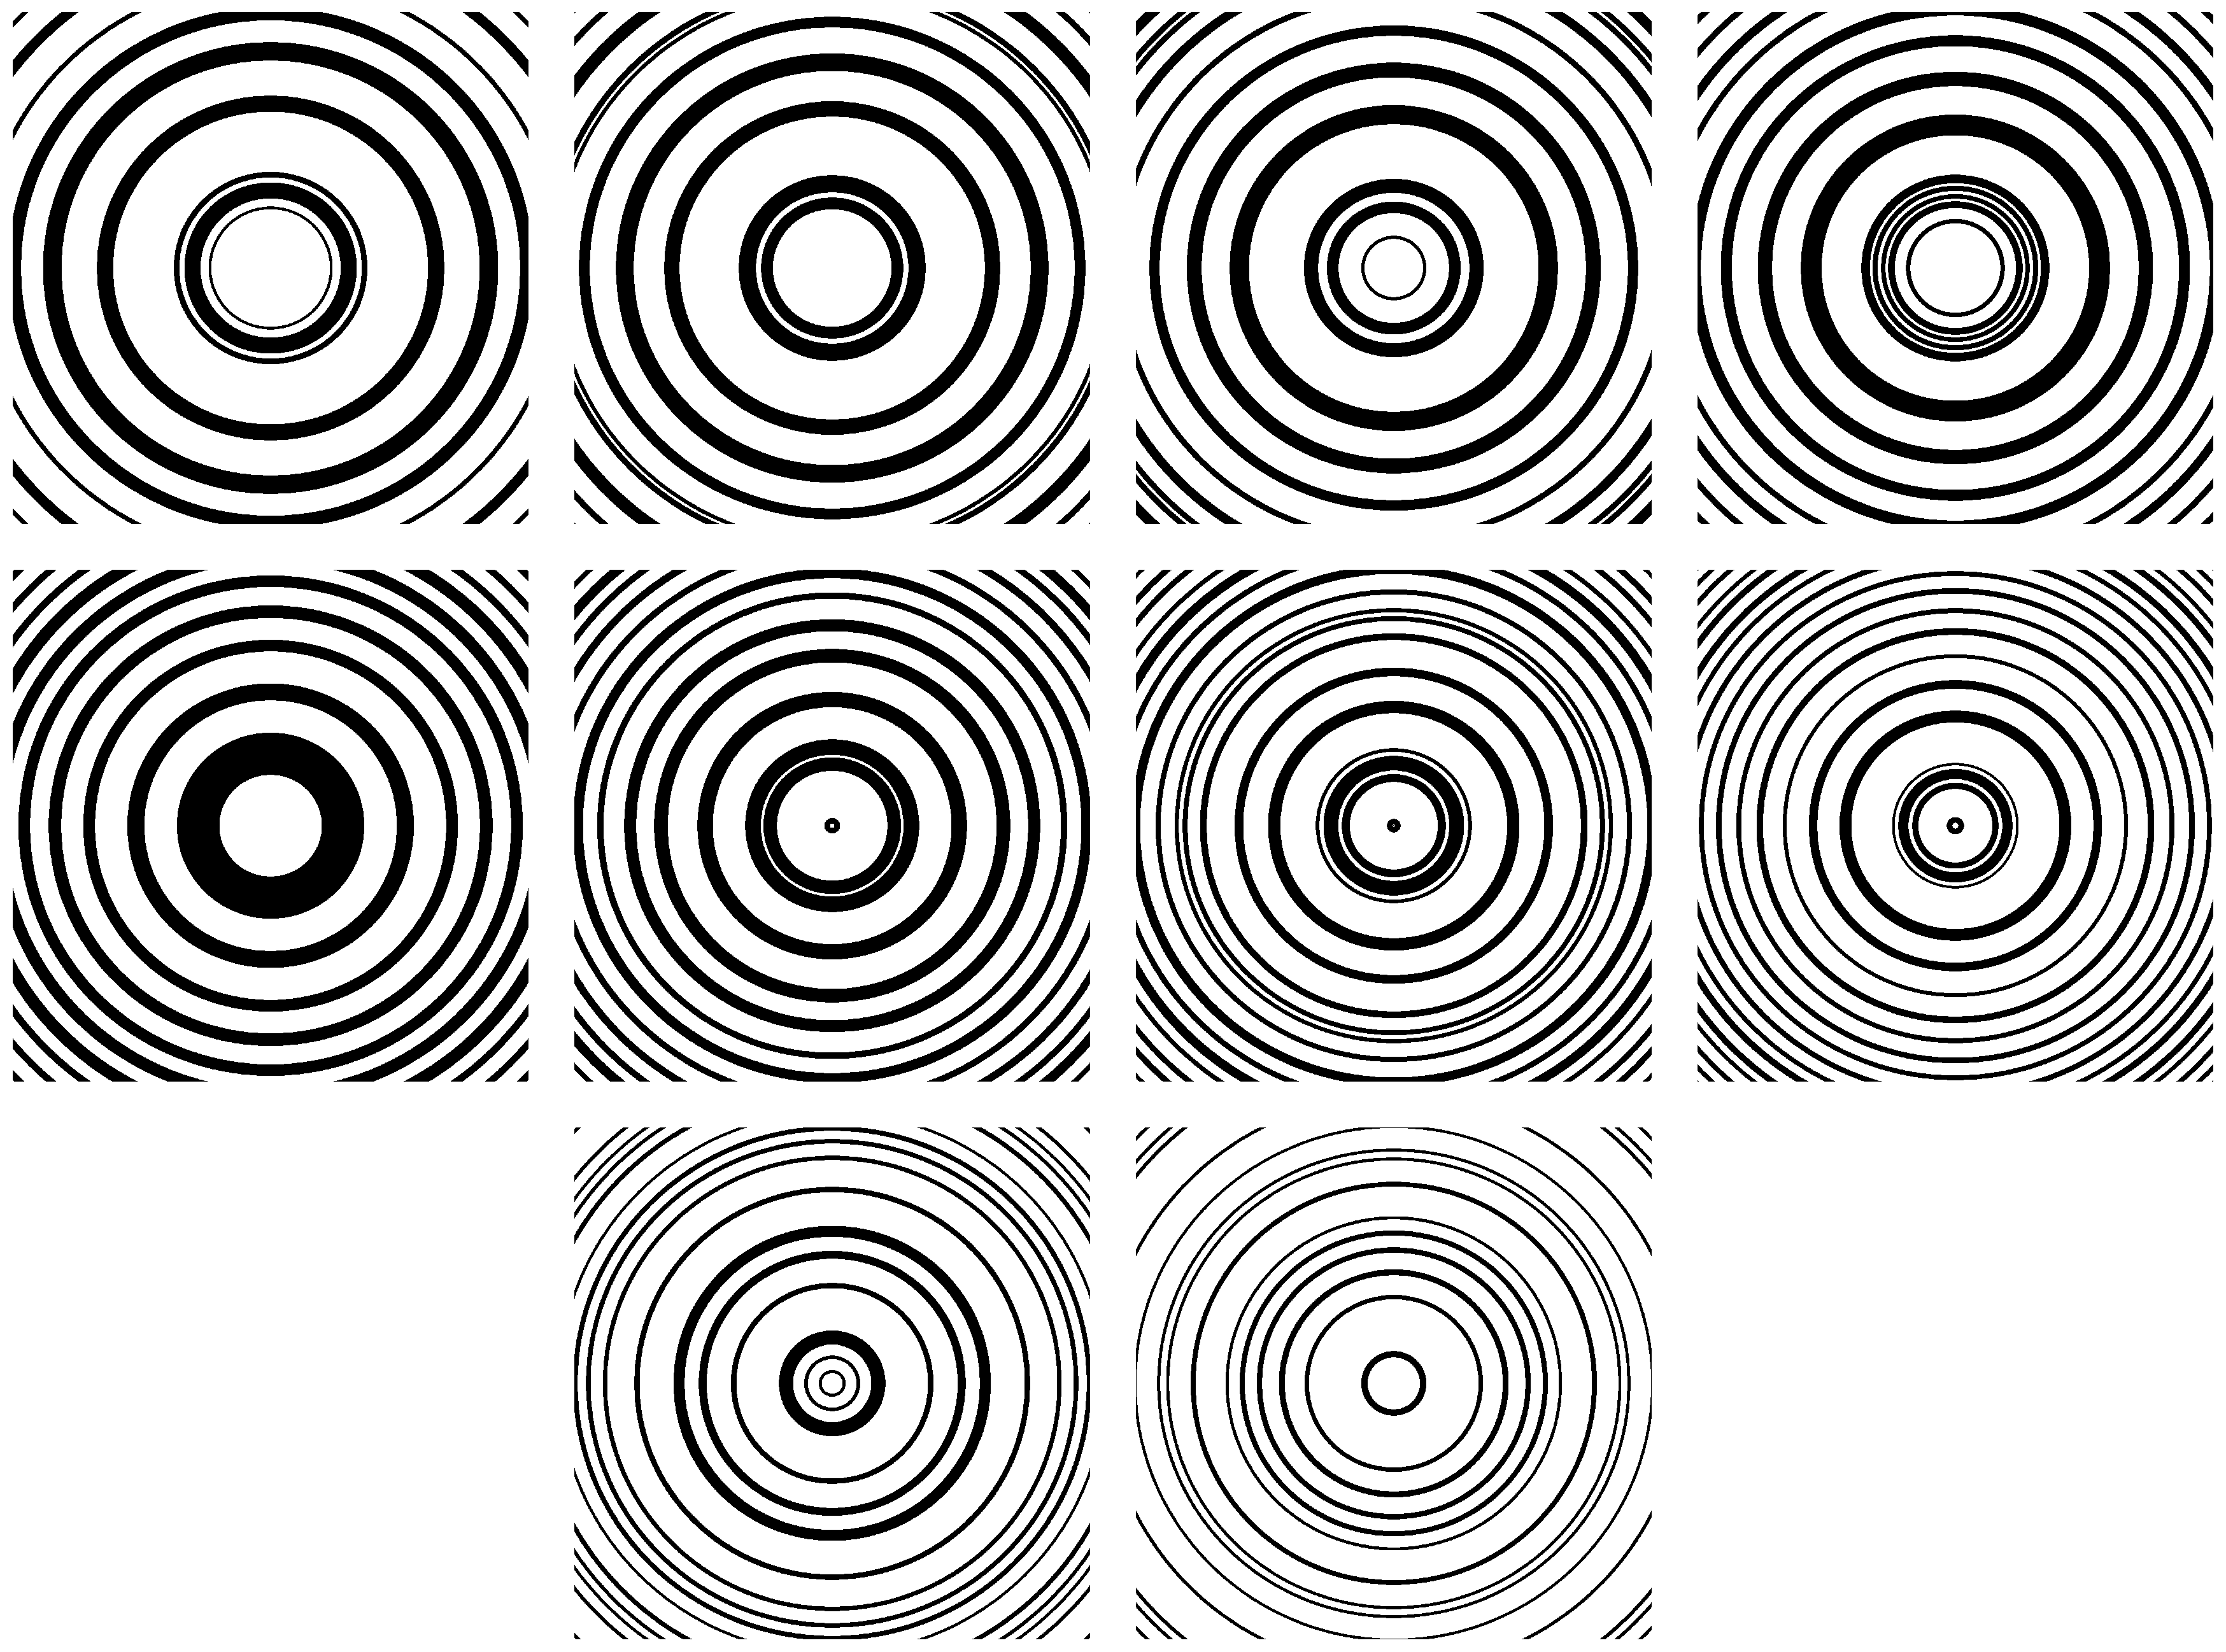

In [15]:
rows = 3
cols = 4
side_length = 10 # um
x_plot = sim_params.x.cpu()[::upsample][Nx//2//upsample - radius_indices:Nx//2//upsample + radius_indices]*1e6
X, Y = np.meshgrid(x_plot, x_plot)

fig, ax = plt.subplots(rows, cols, figsize=(18,13.5))
plt.subplots_adjust(wspace=0.0, hspace=0.0, left=0.01, right=0.8, bottom=0.01, top=0.81, )
for i in range(len(components_2d)):
    row = i // cols
    col = i % cols  
    ax[row, col].pcolormesh(X, Y, components_2d[i], cmap='gray', vmin=0.0, vmax=1.0)
    ax[row, col].set_xlim(-side_length, side_length)
    ax[row, col].set_ylim(-side_length, side_length)
    ax[row, col].axis("off")
plt.tight_layout()
plt.show()

In [10]:
zp_x = zp_init(sim_params.lams[sim_params.lams.argmax()], f, min_feature_size, 1, sim_params)[::upsample]
zp_x_cropped = np.flip(zp_x[zp_x.shape[0]-radius_indices:])
zp_x_2d = 1.0 - spherize_1d_array(zp_x_cropped)

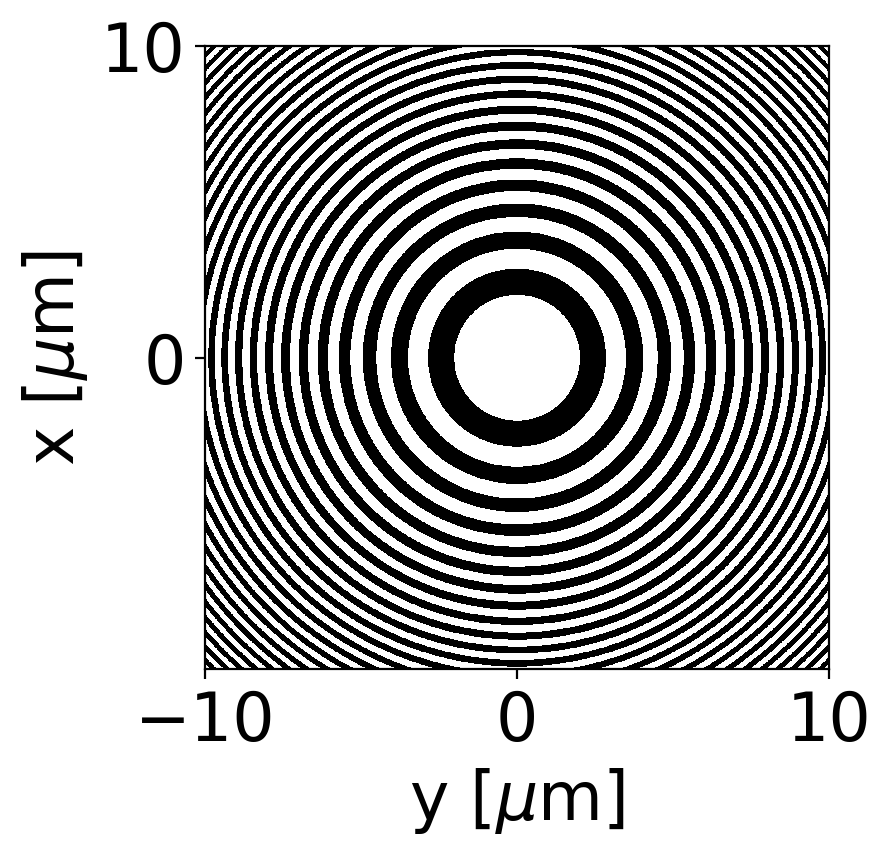

In [11]:
fig, ax = plt.subplots()
xticks = np.arange(-10, 20, 10)
yticks = np.arange(0, 20, 10)
ax.pcolormesh(X, Y, zp_x_2d, cmap='gray')
plt.xlim(-side_length, side_length)
plt.ylim(-side_length, side_length)
plt.xlabel("y [$\\mu$m]")
plt.ylabel("x [$\\mu$m]")
ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()